### Подготовка окружения

In [1]:
from pathlib import Path
import sys

current_path = Path.cwd()
code_path = current_path.parent / 'code'
sys.path.append(str(code_path))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

from thinkdsp import decorate

### Упражнение 8.1

При фиксированном `M` увеличение `std` приводит к обрезанию хвостов гауссианы — окно становится слишком коротким, чтобы вместить полный профиль. После нормировки (деления на сумму) центральная часть недопредставлена, а форма окна перестаёт соответствовать истинной гауссиане. В частотной области это проявляется как искажение АЧХ фильтра: сглаживание становится менее эффективным, появляются нежелательные пульсации. Иными словами, эффективная ширина окна перестаёт контролироваться параметром `std`.

### Упражнение 8.2

Проверим, что Фурье-образ гауссианы — тоже гауссиана (приближённо). Посмотрим, как меняется ДПФ при изменении `std`.

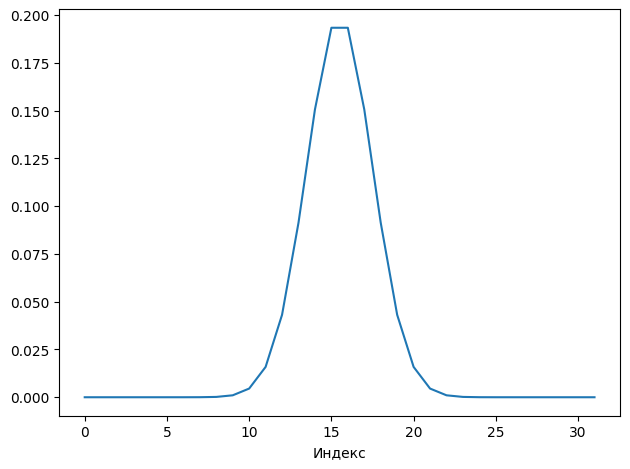

In [4]:
gaussian = scipy.signal.windows.gaussian(M=32, std=2)
gaussian /= sum(gaussian)
plt.plot(gaussian)
decorate(xlabel='Индекс')

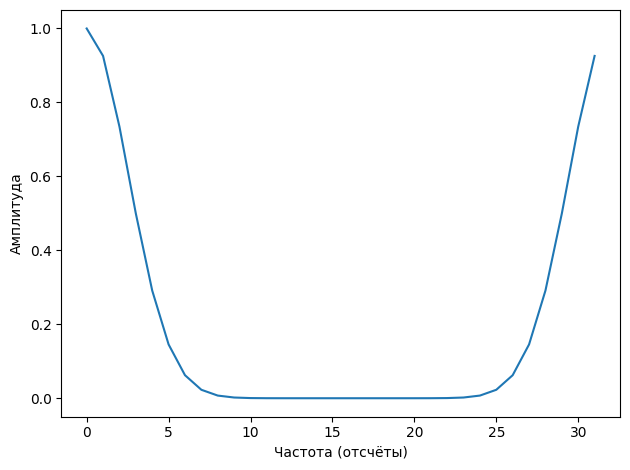

In [5]:
fft_gaussian = np.fft.fft(gaussian)
plt.plot(abs(fft_gaussian))
decorate(xlabel='Частота (отсчёты)', ylabel='Амплитуда')

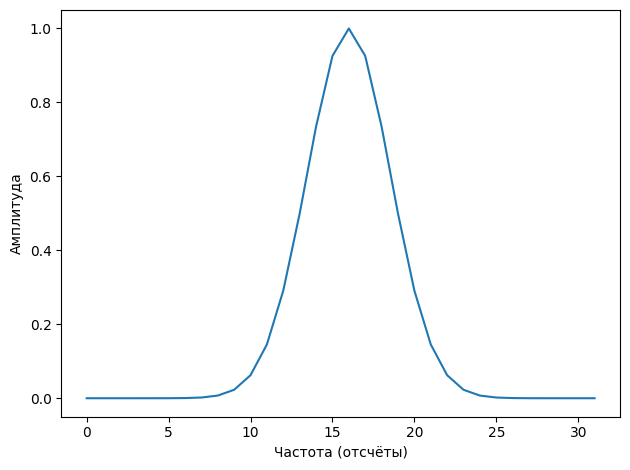

In [6]:
N = len(gaussian)
fft_rolled = np.roll(fft_gaussian, N // 2)
plt.plot(abs(fft_rolled))
decorate(xlabel='Частота (отсчёты)', ylabel='Амплитуда')

In [7]:
def plot_gaussian(std):
    M = 32
    g = scipy.signal.windows.gaussian(M=M, std=std)
    g /= sum(g)

    plt.subplot(1, 2, 1)
    plt.plot(g)
    decorate(xlabel='Время', title=f'std={std}')

    fft_g = np.fft.fft(g)
    fft_rolled = np.roll(fft_g, M // 2)

    plt.subplot(1, 2, 2)
    plt.plot(np.abs(fft_rolled))
    decorate(xlabel='Частота', title='ДПФ')
    plt.tight_layout()

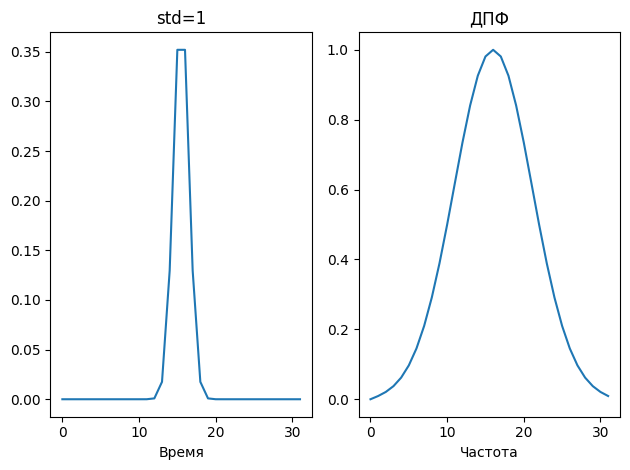

In [8]:
plot_gaussian(1)

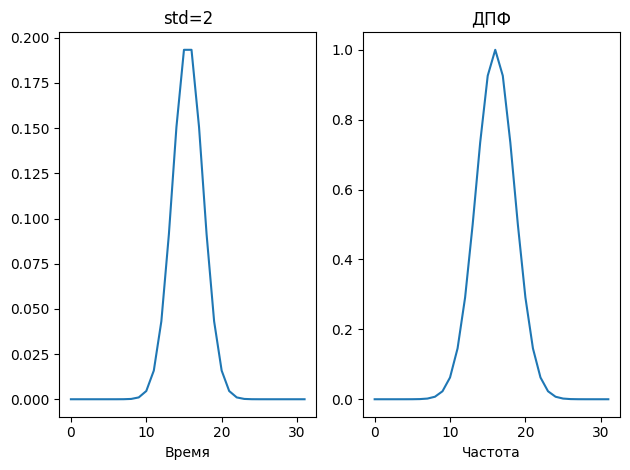

In [9]:
plot_gaussian(2)

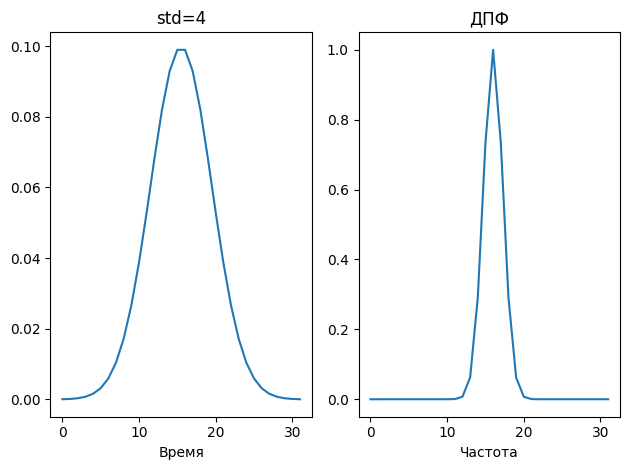

In [10]:
plot_gaussian(4)

При увеличении `std` гауссиана во временной области становится шире, а её ДПФ — уже (обратная зависимость).

### Упражнение 8.3

Сравним разные окна (Hamming, Gaussian, Blackman, Hanning) одинаковой длины: построим их временные формы и ДПФ с дополнением нулями (zero-padding).

In [11]:
M = 15
std = 2.5

gaussian = scipy.signal.windows.gaussian(M=M, std=std)
bartlett = np.bartlett(M)
blackman = np.blackman(M)
hamming = np.hamming(M)
hanning = np.hanning(M)

windows = [blackman, gaussian, hanning, hamming]
names = ['Blackman', 'Gaussian', 'Hanning', 'Hamming']

for w in windows:
    w /= sum(w)

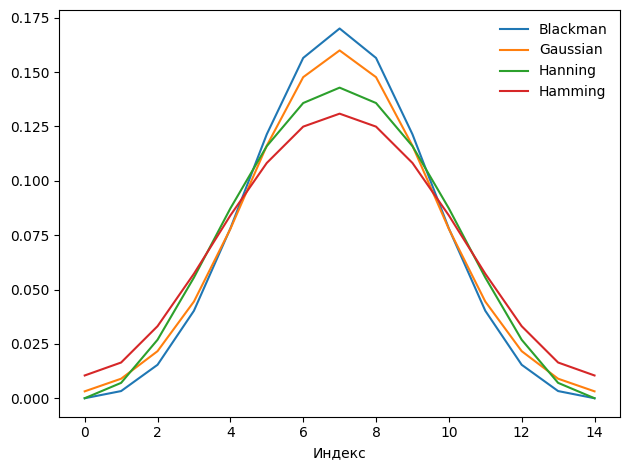

In [12]:
for w, name in zip(windows, names):
    plt.plot(w, label=name)
decorate(xlabel='Индекс')

In [13]:
from thinkdsp import SquareSignal

signal = SquareSignal(freq=440)
wave = signal.make_wave(duration=1.0, framerate=44100)

def zero_pad(array, n):
    res = np.zeros(n)
    res[:len(array)] = array
    return res

In [14]:
def plot_window_dfts(windows, names):
    for w, name in zip(windows, names):
        padded = zero_pad(w, len(wave))
        dft_w = np.fft.rfft(padded)
        plt.plot(abs(dft_w), label=name)

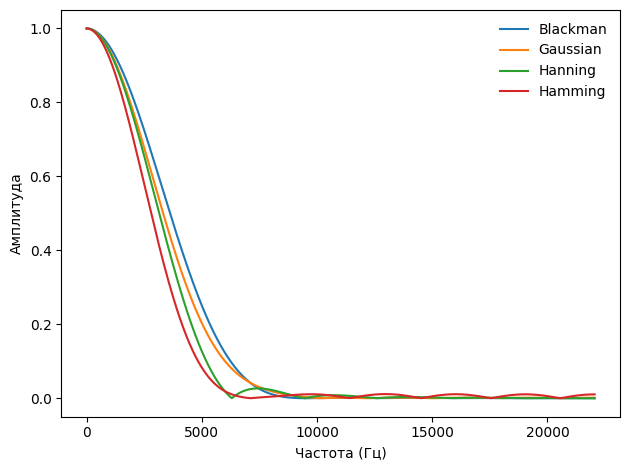

In [15]:
plot_window_dfts(windows, names)
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

На логарифмической шкале видно, что:
- Hanning и Hamming быстрее всего подавляют высокие частоты (крутой спад) и имеют самые низкие боковые лепестки.
- Blackman спадает медленнее всех.
- Gaussian занимает промежуточное положение.

По совокупности Hanning выглядит лучшим low-pass фильтром среди рассмотренных благодаря быстрому спаду.